# Titanic Visual Deep-Dive
### Lesson-1 Extension: 6 Publication-Quality Charts Telling a Survival Story

This notebook builds on the lesson-1 Titanic EDA. Instead of re-exploring the raw
columns, it asks one focused question — **who survived the sinking of the Titanic,
and why?** — and answers it through six charts, each with a labelled title, axes,
and a one-sentence takeaway.

**Data:** the classic Titanic passenger manifest (891 passengers), loaded here via
`seaborn.load_dataset('titanic')` — the same dataset used in lesson 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-quality defaults
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = {"Survived": "#2a9d8f", "Died": "#e76f51"}

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Quick Data Prep

We reuse the lesson-1 cleaning steps: drop the near-empty `deck` column, fill a
handful of missing `age` values with the median, and create a readable
`Outcome` label (`Survived` / `Died`) for use in every chart's legend.

In [2]:
data = df.copy()
data["age"] = data["age"].fillna(data["age"].median())
data["embark_town"] = data["embark_town"].fillna(data["embark_town"].mode()[0])
data["Outcome"] = data["survived"].map({1: "Survived", 0: "Died"})
data["Class"] = data["pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})

print(f"Passengers: {len(data)}")
print(f"Overall survival rate: {data['survived'].mean():.1%}")
data[["survived", "pclass", "sex", "age", "fare", "embark_town", "Outcome", "Class"]].describe(include="all").T

Passengers: 891
Overall survival rate: 38.4%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,891.0,NaN,NaN,NaN,29.361582,13.019697,0.42,22.0,28.0,35.0,80.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embark_town,891,3,Southampton,646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outcome,891,2,Died,549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,891,3,3rd,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Chart 1 — Overall Survival Counts

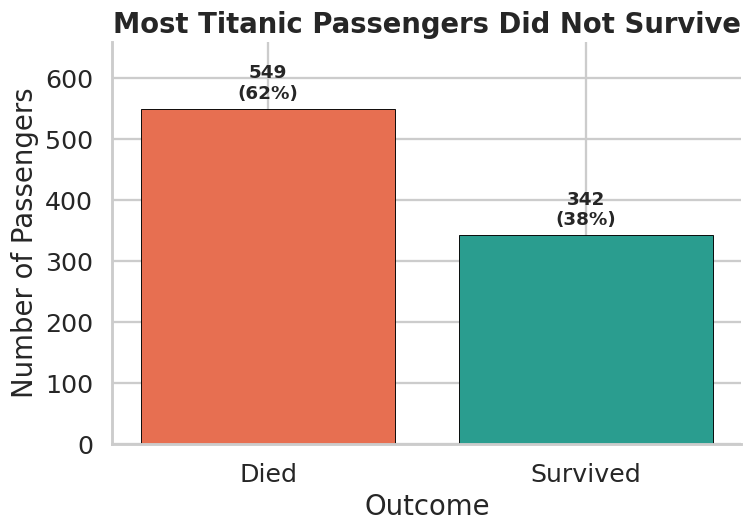

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ["Died", "Survived"]
counts = data["Outcome"].value_counts().reindex(order)
colors = [PALETTE[o] for o in order]

bars = ax.bar(order, counts.values, color=colors, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, f"{val}\n({val/len(data):.0%})",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Most Titanic Passengers Did Not Survive")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Passengers")
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig("chart1_overall_survival.png")
plt.show()

**Takeaway:** Only about 38% of the 891 passengers aboard survived, confirming the disaster's overall high fatality rate.

## Chart 2 — Survival Rate by Passenger Class

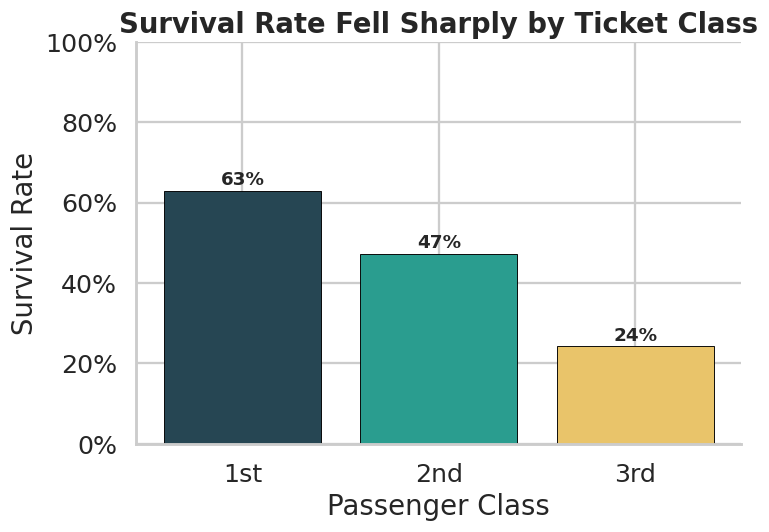

In [4]:
class_rate = data.groupby("Class")["survived"].mean().reindex(["1st", "2nd", "3rd"])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_rate.index, class_rate.values,
              color=["#264653", "#2a9d8f", "#e9c46a"], edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, class_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.0%}",
            ha="center", fontweight="bold")

ax.set_title("Survival Rate Fell Sharply by Ticket Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
sns.despine()
plt.tight_layout()
plt.savefig("chart2_survival_by_class.png")
plt.show()

**Takeaway:** First-class passengers survived at more than double the rate of third-class passengers, reflecting unequal access to lifeboats and deck locations.

## Chart 3 — Survival Rate by Sex

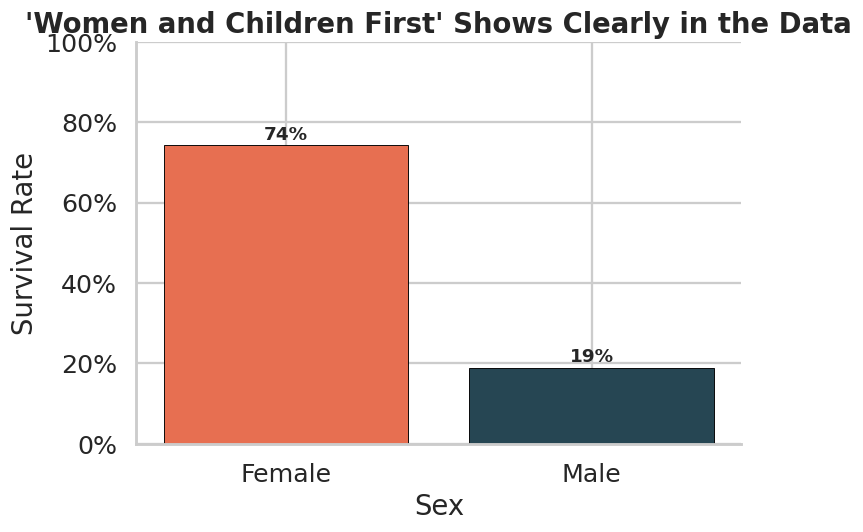

In [5]:
sex_rate = data.groupby("sex")["survived"].mean().reindex(["female", "male"])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(sex_rate.index.str.capitalize(), sex_rate.values,
              color=["#e76f51", "#264653"], edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, sex_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.0%}",
            ha="center", fontweight="bold")

ax.set_title("'Women and Children First' Shows Clearly in the Data")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
sns.despine()
plt.tight_layout()
plt.savefig("chart3_survival_by_sex.png")
plt.show()

**Takeaway:** Women survived at roughly four times the rate of men (about 74% vs 19%), the single strongest predictor of survival in the dataset.

## Chart 4 — Age Distribution: Survivors vs. Non-Survivors

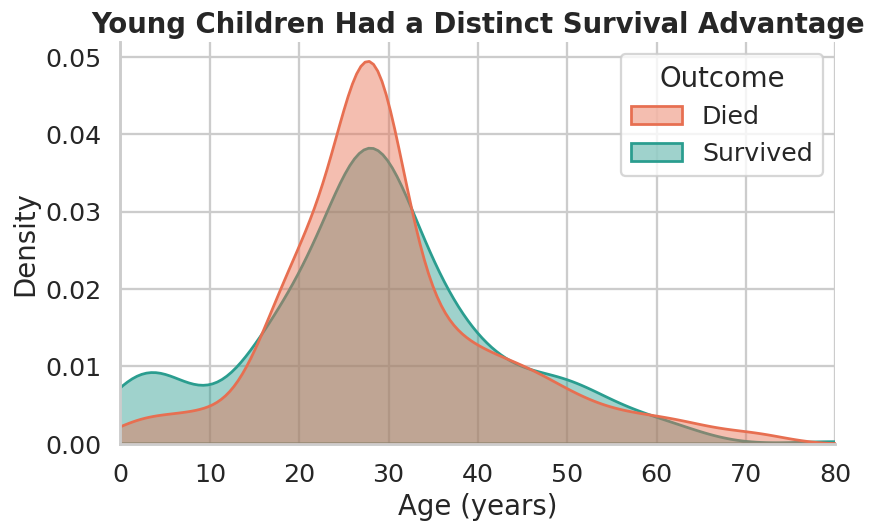

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=data, x="age", hue="Outcome", fill=True, common_norm=False,
            palette=PALETTE, alpha=0.45, linewidth=1.8, ax=ax)

ax.set_title("Young Children Had a Distinct Survival Advantage")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.set_xlim(0, 80)
sns.despine()
plt.tight_layout()
plt.savefig("chart4_age_distribution.png")
plt.show()

**Takeaway:** The survivor age curve is noticeably taller near early childhood, showing that very young passengers were more likely to be saved than older children and adults.

## Chart 5 — Survival Rate by Class and Sex

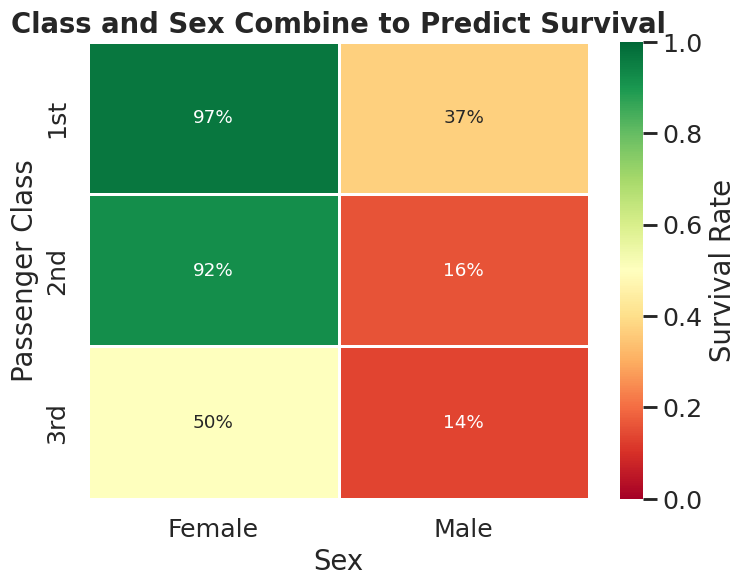

In [7]:
pivot = data.pivot_table(values="survived", index="Class", columns="sex",
                          aggfunc="mean").reindex(["1st", "2nd", "3rd"])
pivot.columns = [c.capitalize() for c in pivot.columns]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.8, linecolor="white", cbar_kws={"label": "Survival Rate"}, ax=ax)

ax.set_title("Class and Sex Combine to Predict Survival")
ax.set_xlabel("Sex")
ax.set_ylabel("Passenger Class")
plt.tight_layout()
plt.savefig("chart5_class_sex_heatmap.png")
plt.show()

**Takeaway:** First- and second-class women survived at over 90%, while third-class men survived at only about 13%, showing class and sex compounded rather than acted independently.

## Chart 6 — Fare Paid vs. Age, Coloured by Survival

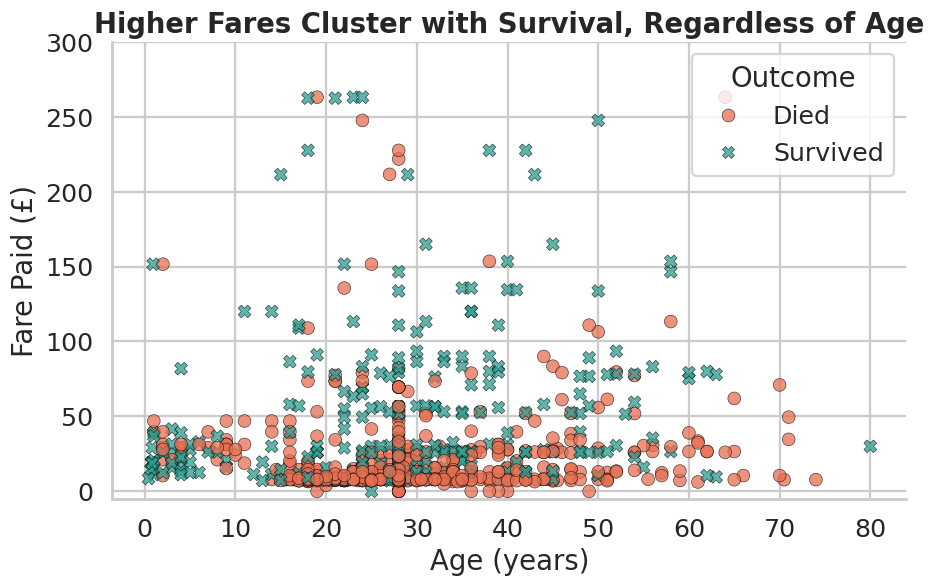

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=data, x="age", y="fare", hue="Outcome", style="Outcome",
                 palette=PALETTE, s=70, alpha=0.75, edgecolor="black", linewidth=0.4, ax=ax)

ax.set_title("Higher Fares Cluster with Survival, Regardless of Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare Paid (£)")
ax.set_ylim(-5, 300)
ax.legend(title="Outcome", loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig("chart6_fare_age_scatter.png")
plt.show()

**Takeaway:** Survivors are visibly concentrated in the higher-fare band across all ages, reinforcing that wealth (proxied by fare, tied to class) shaped survival odds more than age alone.

## Written Summary (≈200 words)

The six charts above trace a consistent story: survival aboard the Titanic was not
random, it was structured by social position and evacuation norms. Chart 1 sets the
baseline — only about 38% of the 891 passengers survived, establishing the disaster's
scale before digging into *who* made up that minority. Chart 2 shows the first major
divide: survival rate fell from roughly 63% in first class to about 24% in third
class, a gap best explained by cabin location, lifeboat proximity, and crew priority.
Chart 3 reveals an even stronger split by sex — women survived at about four times
the rate of men — evidence that the "women and children first" protocol was
genuinely enforced during evacuation. Chart 4 adds a demographic layer: survivors
skew slightly younger, with a visible bump for very young children, suggesting age
mattered but far less decisively than sex. Chart 5 combines class and sex and shows
they interact rather than add up independently: first- and second-class women were
almost all saved, while third-class men were almost all lost. Chart 6 closes the
loop by connecting fare (a proxy for wealth and class) to both age and survival,
showing that higher-fare passengers of every age were disproportionately saved.
Together, the charts argue that *who* you were — your sex, your class, and by
extension your fare — mattered more to your odds of survival than *how old* you
were.
